# RAG Evaluation Criteria for Production Systems
### A Comprehensive Guide for ML Engineers

**Author:** Akshay Ratnawat
**Target Audience:** ML Engineers  
**Date:** December 2025

---

## 📚 Table of Contents

1. [Introduction to RAG Evaluation](#intro)
2. [Why Evaluation Matters in Production](#why)
3. [Setup & Dependencies](#setup)
4. [Creating Sample Dataset](#dataset)
5. [Retrieval Quality Metrics](#retrieval)
6. [Generation Quality Metrics](#generation)
7. [Production Monitoring](#production)
8. [Putting It All Together](#summary)

---

## What You'll Learn

By the end of this notebook, you'll understand:

- **Core RAG evaluation metrics** used in production
- **How to measure retrieval quality** (Precision@K, Recall@K, MRR, NDCG)
- **How to evaluate generation quality** (Faithfulness, Relevance, Hallucination)
- **Production considerations** (Latency, Cost, User Feedback)
- **Practical implementation** with hands-on examples

Let's dive in! 🚀

## 1. Introduction to RAG <a id='intro'></a>

### What is RAG (Retrieval-Augmented Generation)?

RAG is a powerful architecture that combines:

1. **Retrieval System**: Searches through a knowledge base to find relevant documents/chunks
2. **Generation System**: Uses an LLM to generate answers based on retrieved context

```
User Query → Retrieval → Retrieved Contexts → LLM Generation → Answer
```

### The RAG Pipeline

```
┌─────────────┐      ┌──────────────┐      ┌─────────────┐
│ User Query  │──→   │  Retriever   │──→   │ Top-K Docs  │
└─────────────┘      └──────────────┘      └─────────────┘
                                                    ↓
┌─────────────┐      ┌──────────────┐      ┌─────────────┐
│Final Answer │←──   │  LLM (GPT-4) │←──   │   Prompt    │
└─────────────┘      └──────────────┘      └─────────────┘
```

### Why RAG Evaluation is Critical

In production, you need to ensure:
- ✅ **Retrieval retrieves the RIGHT documents** (not just similar-looking ones)
- ✅ **LLM generates ACCURATE answers** (grounded in retrieved context)
- ✅ **System is FAST enough** (latency < 2-3 seconds for user experience)
- ✅ **Costs are REASONABLE** (API costs can add up quickly)
- ✅ **Quality doesn't DEGRADE** over time (drift detection)

**Without proper evaluation, you're flying blind! 🎯**

## 2. Why Evaluation Matters in Production <a id='why'></a>

### The Production Reality Check

In research/prototyping, you might ask:
- *"Does this work?"*

In production, you need to ask:
- *"Does this work **reliably** for 100,000 users daily?"*
- *"Can I detect when quality degrades?"*
- *"How do I compare System A vs System B?"*
- *"What's my cost per 1,000 queries?"*

### Key Evaluation Categories

| Category | What It Measures | Example Metrics |
|----------|------------------|-----------------|
| 🔍 **Retrieval Quality** | Are we finding the right documents? | Precision@K, Recall@K, MRR, NDCG |
| 📝 **Generation Quality** | Is the answer correct and grounded? | Faithfulness, Relevance, F1 Score |
| ⚡ **System Performance** | Is it fast enough? | Latency (p50, p95, p99) |
| 💰 **Cost Efficiency** | Can we afford to scale? | Cost per query, Token usage |
| 📊 **User Satisfaction** | Do users like it? | Thumbs up/down, CSAT score |

### The Evaluation Framework

```python
# Pseudo-code for production RAG evaluation
def evaluate_rag_system(queries, ground_truth):
    results = {
        'retrieval': evaluate_retrieval(queries),      # Step 1
        'generation': evaluate_generation(queries),    # Step 2
        'performance': measure_latency(queries),       # Step 3
        'cost': calculate_cost(queries),               # Step 4
        'user_feedback': collect_feedback(queries)     # Step 5
    }
    return combined_score(results)
```

**Let's implement each of these! 💪**

## 3. Setup & Dependencies <a id='setup'></a>

We'll use minimal dependencies to keep things clear. In production, you'd use frameworks like:
- **RAGAS** (RAG Assessment)
- **TruLens** (LLM evaluation & tracking)
- **LangSmith** (LangChain's evaluation suite)

For this tutorial, we'll implement from scratch to understand the fundamentals!

In [3]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Tuple
import re
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# For text similarity (we'll use simple implementations)
from difflib import SequenceMatcher

# Set random seed for reproducibility
np.random.seed(42)

# Plotting style
sns.set_theme(style="darkgrid")
sns.set_palette("Set2")  # Use a colorblind-friendly palette

print("✅ All libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

✅ All libraries imported successfully!
NumPy version: 1.22.2
Pandas version: 1.2.4


## 4. Creating Sample Dataset <a id='dataset'></a>

### Dataset Structure

For RAG evaluation, we need:

1. **Query**: User's question
2. **Ground Truth Answer**: The correct answer (from human experts)
3. **Retrieved Contexts**: Documents fetched by the retrieval system
4. **Ground Truth Contexts**: Which contexts SHOULD have been retrieved
5. **Generated Answer**: What the LLM actually produced

Let's create a realistic dataset about "Python Programming" to make it relatable!

In [4]:
# Create a knowledge base (simulated documents)
knowledge_base = {
    "doc_1": "Python lists are mutable, ordered collections that can contain elements of different types. Lists support indexing, slicing, and various methods like append(), extend(), and pop().",
    "doc_2": "Python dictionaries are unordered collections of key-value pairs. They provide O(1) average time complexity for lookups and are implemented using hash tables.",
    "doc_3": "List comprehensions in Python provide a concise way to create lists. The syntax is [expression for item in iterable if condition]. They are more readable and often faster than traditional for loops.",
    "doc_4": "Python decorators are functions that modify the behavior of other functions. They use the @decorator syntax and are commonly used for logging, authentication, and memoization.",
    "doc_5": "The Global Interpreter Lock (GIL) in Python prevents multiple threads from executing Python bytecode simultaneously. This makes threading ineffective for CPU-bound tasks but acceptable for I/O-bound operations.",
    "doc_6": "Python generators are functions that use yield instead of return. They create iterators lazily, saving memory by generating values on-the-fly rather than storing entire sequences.",
    "doc_7": "Exception handling in Python uses try-except blocks. Python follows the EAFP principle (Easier to Ask for Forgiveness than Permission) rather than LBYL (Look Before You Leap).",
    "doc_8": "Python's asyncio library enables asynchronous programming using async/await syntax. It's ideal for I/O-bound concurrent tasks like web requests or database queries.",
    "doc_9": "Python sets are unordered collections of unique elements. They support mathematical set operations like union, intersection, and difference with O(1) membership testing.",
    "doc_10": "Context managers in Python use the 'with' statement to ensure proper resource management. They implement __enter__ and __exit__ methods for setup and cleanup operations.",
}

print(f"📚 Knowledge Base: {len(knowledge_base)} documents")
print("\nSample document:")
print(f"doc_1: {knowledge_base['doc_1']}")

📚 Knowledge Base: 10 documents

Sample document:
doc_1: Python lists are mutable, ordered collections that can contain elements of different types. Lists support indexing, slicing, and various methods like append(), extend(), and pop().


In [5]:
# Create evaluation dataset
# Each example simulates a RAG pipeline execution

eval_data = [
    {
        "query": "What are Python list comprehensions and why use them?",
        "ground_truth_answer": "List comprehensions provide a concise syntax to create lists using the format [expression for item in iterable if condition]. They are more readable and often faster than traditional loops.",
        "ground_truth_contexts": ["doc_3"],  # Which docs SHOULD be retrieved
        "retrieved_contexts": ["doc_3", "doc_1", "doc_9"],  # What was actually retrieved (top-3)
        "generated_answer": "List comprehensions in Python provide a concise way to create lists with syntax [expression for item in iterable if condition]. They are more readable and faster than for loops.",
        "retrieval_scores": [0.95, 0.72, 0.45],  # Similarity scores from retriever
    },
    {
        "query": "How do Python dictionaries work internally?",
        "ground_truth_answer": "Python dictionaries are implemented using hash tables, which provide O(1) average time complexity for lookups. They store key-value pairs in an unordered collection.",
        "ground_truth_contexts": ["doc_2"],
        "retrieved_contexts": ["doc_2", "doc_9", "doc_1"],
        "generated_answer": "Dictionaries use hash tables internally for O(1) lookups and store unordered key-value pairs.",
        "retrieval_scores": [0.89, 0.58, 0.51],
    },
    {
        "query": "What is the GIL in Python?",
        "ground_truth_answer": "The Global Interpreter Lock (GIL) prevents multiple threads from executing Python bytecode simultaneously, making threading ineffective for CPU-bound tasks but acceptable for I/O-bound operations.",
        "ground_truth_contexts": ["doc_5"],
        "retrieved_contexts": ["doc_5", "doc_8", "doc_6"],
        "generated_answer": "The GIL (Global Interpreter Lock) prevents multiple threads from executing Python code at the same time. This impacts CPU-bound tasks but not I/O-bound operations.",
        "retrieval_scores": [0.92, 0.61, 0.48],
    },
    {
        "query": "Explain Python decorators",
        "ground_truth_answer": "Decorators are functions that modify the behavior of other functions using @decorator syntax. They're commonly used for logging, authentication, and memoization.",
        "ground_truth_contexts": ["doc_4"],
        "retrieved_contexts": ["doc_4", "doc_6", "doc_3"],
        "generated_answer": "Python decorators modify function behavior using @ syntax. Common uses include logging, authentication, and caching.",
        "retrieval_scores": [0.88, 0.55, 0.42],
    },
    {
        "query": "What are generators in Python?",
        "ground_truth_answer": "Generators use yield instead of return to create iterators lazily. They generate values on-the-fly, saving memory compared to storing entire sequences.",
        "ground_truth_contexts": ["doc_6"],
        "retrieved_contexts": ["doc_6", "doc_3", "doc_5"],
        "generated_answer": "Generators use yield to create iterators that generate values lazily, which saves memory.",
        "retrieval_scores": [0.91, 0.48, 0.44],
    },
    {
        "query": "How does async/await work in Python?",
        "ground_truth_answer": "Python's asyncio enables asynchronous programming with async/await syntax. It's ideal for I/O-bound concurrent tasks like web requests or database queries.",
        "ground_truth_contexts": ["doc_8"],
        "retrieved_contexts": ["doc_8", "doc_5", "doc_10"],
        "generated_answer": "Asyncio with async/await allows asynchronous programming in Python, perfect for I/O-bound tasks like web requests.",
        "retrieval_scores": [0.87, 0.62, 0.39],
    },
    {
        "query": "What's the difference between lists and sets?",
        "ground_truth_answer": "Lists are ordered, mutable collections that allow duplicates, while sets are unordered collections of unique elements with O(1) membership testing.",
        "ground_truth_contexts": ["doc_1", "doc_9"],
        "retrieved_contexts": ["doc_1", "doc_9", "doc_2"],
        "generated_answer": "Lists are ordered and allow duplicates, while sets are unordered with unique elements and fast membership testing.",
        "retrieval_scores": [0.79, 0.76, 0.58],
    },
    {
        "query": "What are context managers used for?",
        "ground_truth_answer": "Context managers use the 'with' statement for proper resource management. They implement __enter__ and __exit__ methods for setup and cleanup.",
        "ground_truth_contexts": ["doc_10"],
        "retrieved_contexts": ["doc_10", "doc_7", "doc_4"],
        "generated_answer": "Context managers use 'with' statements to manage resources with __enter__ and __exit__ methods for setup/cleanup.",
        "retrieval_scores": [0.90, 0.52, 0.47],
    },
    # Example with poor retrieval (wrong docs retrieved)
    {
        "query": "How to handle exceptions in Python?",
        "ground_truth_answer": "Python uses try-except blocks for exception handling, following the EAFP principle (Easier to Ask for Forgiveness than Permission).",
        "ground_truth_contexts": ["doc_7"],
        "retrieved_contexts": ["doc_4", "doc_10", "doc_3"],  # Wrong docs!
        "generated_answer": "Python handles exceptions using decorators and context managers for error management.",  # Hallucinated!
        "retrieval_scores": [0.68, 0.65, 0.61],
    },
    # Example with partial retrieval
    {
        "query": "What makes Python lists special?",
        "ground_truth_answer": "Lists are mutable, ordered collections supporting indexing, slicing, and methods like append(), extend(), and pop(). They can contain elements of different types.",
        "ground_truth_contexts": ["doc_1"],
        "retrieved_contexts": ["doc_1", "doc_3", "doc_2"],
        "generated_answer": "Python lists are mutable ordered collections with indexing and methods like append() and pop().",
        "retrieval_scores": [0.85, 0.71, 0.59],
    },
]

# Convert to DataFrame for easier analysis
df_eval = pd.DataFrame(eval_data)

print(f"✅ Created evaluation dataset with {len(df_eval)} examples")
print(f"\nColumns: {list(df_eval.columns)}")
print(f"\nFirst example:")
print(f"Query: {df_eval.iloc[0]['query']}")
print(f"Retrieved: {df_eval.iloc[0]['retrieved_contexts']}")
print(f"Ground Truth Docs: {df_eval.iloc[0]['ground_truth_contexts']}")

✅ Created evaluation dataset with 10 examples

Columns: ['query', 'ground_truth_answer', 'ground_truth_contexts', 'retrieved_contexts', 'generated_answer', 'retrieval_scores']

First example:
Query: What are Python list comprehensions and why use them?
Retrieved: ['doc_3', 'doc_1', 'doc_9']
Ground Truth Docs: ['doc_3']


## 5. Retrieval Quality Metrics <a id='retrieval'></a>

### Why Retrieval Quality Matters

**Garbage In = Garbage Out!** 🗑️

Even the best LLM (GPT-4, Claude, etc.) can't generate good answers if the retrieval system provides:
- Irrelevant documents
- Missing key information
- Too many low-quality results

### Key Retrieval Metrics

| Metric | What It Measures | When to Use |
|--------|------------------|-------------|
| **Precision@K** | Of the K retrieved docs, how many are relevant? | When you care about quality over quantity |
| **Recall@K** | Of all relevant docs, how many did we retrieve? | When you need comprehensive coverage |
| **MRR** (Mean Reciprocal Rank) | How quickly do we find the first relevant doc? | When first result matters most (search) |
| **NDCG** (Normalized Discounted Cumulative Gain) | How well-ranked are results? | When ranking quality matters |
| **Context Relevance** | Is retrieved text actually useful for the query? | RAG-specific quality check |

Let's implement each one! 🔨

### 5.1 Precision@K

**Definition:** Of the K documents retrieved, what fraction are actually relevant?

**Formula:**
$$\text{Precision@K} = \frac{\text{Relevant docs in top-K}}{\text{K}}$$

**Example:**
- Retrieved top-3: [doc_3, doc_1, doc_9]
- Relevant: [doc_3]
- Precision@3 = 1/3 = 0.33

**When to use:** 
- You want high-quality results
- False positives are costly (e.g., legal/medical RAG)

In [6]:
def precision_at_k(retrieved_contexts: List[str], ground_truth_contexts: List[str], k: int) -> float:
    """
    Calculate Precision@K
    
    Args:
        retrieved_contexts: List of retrieved document IDs (in order)
        ground_truth_contexts: List of truly relevant document IDs
        k: Number of top results to consider
    
    Returns:
        Precision@K score (0.0 to 1.0)
    """
    # Take only top-k retrieved
    retrieved_at_k = retrieved_contexts[:k]
    
    # Count how many are relevant
    relevant_count = sum(1 for doc in retrieved_at_k if doc in ground_truth_contexts)
    
    # Precision = relevant / total retrieved
    return relevant_count / k if k > 0 else 0.0


# Test on our dataset
print("📊 Precision@K Analysis\n")
print("="*80)

for k in [1, 3, 5]:
    precisions = []
    for idx, row in df_eval.iterrows():
        prec = precision_at_k(row['retrieved_contexts'], row['ground_truth_contexts'], k)
        precisions.append(prec)
    
    avg_precision = np.mean(precisions)
    print(f"Average Precision@{k}: {avg_precision:.3f}")

print("\n" + "="*80)
print("\n📋 Per-Query Precision@3:")
for idx, row in df_eval.iterrows():
    prec = precision_at_k(row['retrieved_contexts'], row['ground_truth_contexts'], k=3)
    print(f"Query {idx+1}: {prec:.2f} | Retrieved: {row['retrieved_contexts'][:3]} | Relevant: {row['ground_truth_contexts']}")

📊 Precision@K Analysis

Average Precision@1: 0.900
Average Precision@3: 0.333
Average Precision@5: 0.200


📋 Per-Query Precision@3:
Query 1: 0.33 | Retrieved: ['doc_3', 'doc_1', 'doc_9'] | Relevant: ['doc_3']
Query 2: 0.33 | Retrieved: ['doc_2', 'doc_9', 'doc_1'] | Relevant: ['doc_2']
Query 3: 0.33 | Retrieved: ['doc_5', 'doc_8', 'doc_6'] | Relevant: ['doc_5']
Query 4: 0.33 | Retrieved: ['doc_4', 'doc_6', 'doc_3'] | Relevant: ['doc_4']
Query 5: 0.33 | Retrieved: ['doc_6', 'doc_3', 'doc_5'] | Relevant: ['doc_6']
Query 6: 0.33 | Retrieved: ['doc_8', 'doc_5', 'doc_10'] | Relevant: ['doc_8']
Query 7: 0.67 | Retrieved: ['doc_1', 'doc_9', 'doc_2'] | Relevant: ['doc_1', 'doc_9']
Query 8: 0.33 | Retrieved: ['doc_10', 'doc_7', 'doc_4'] | Relevant: ['doc_10']
Query 9: 0.00 | Retrieved: ['doc_4', 'doc_10', 'doc_3'] | Relevant: ['doc_7']
Query 10: 0.33 | Retrieved: ['doc_1', 'doc_3', 'doc_2'] | Relevant: ['doc_1']


### 5.2 Recall@K

**Definition:** Of all the relevant documents that exist, what fraction did we retrieve in top-K?

**Formula:**
$$\text{Recall@K} = \frac{\text{No of Relevant docs in top-K}}{\text{Total No of relevant docs}}$$

**Example:**
- Ground truth relevant: [doc_3, doc_1] (2 documents)
- Retrieved top-3: [doc_3, doc_2, doc_9]
- Found: [doc_3] → 1 out of 2
- Recall@3 = 1/2 = 0.50

**When to use:**
- You need comprehensive coverage (e.g., research, discovery)
- Missing information is worse than extra information

In [7]:
def recall_at_k(retrieved_contexts: List[str], ground_truth_contexts: List[str], k: int) -> float:
    """
    Calculate Recall@K
    
    Args:
        retrieved_contexts: List of retrieved document IDs
        ground_truth_contexts: List of truly relevant document IDs
        k: Number of top results to consider
    
    Returns:
        Recall@K score (0.0 to 1.0)
    """
    if len(ground_truth_contexts) == 0:
        return 0.0
    
    retrieved_at_k = retrieved_contexts[:k]
    
    # Count how many relevant docs we found
    found_count = sum(1 for doc in ground_truth_contexts if doc in retrieved_at_k)
    
    # Recall = found / total relevant
    return found_count / len(ground_truth_contexts)


# Test on our dataset
print("📊 Recall@K Analysis\n")
print("="*80)

for k in [1, 3, 5]:
    recalls = []
    for idx, row in df_eval.iterrows():
        rec = recall_at_k(row['retrieved_contexts'], row['ground_truth_contexts'], k)
        recalls.append(rec)
    
    avg_recall = np.mean(recalls)
    print(f"Average Recall@{k}: {avg_recall:.3f}")

print("\n" + "="*80)
print("\n🎯 Precision vs Recall Trade-off (K=3):")
print(f"{'Query':<50} {'Precision@3':<15} {'Recall@3':<15}")
print("-"*80)

for idx, row in df_eval.iterrows():
    prec = precision_at_k(row['retrieved_contexts'], row['ground_truth_contexts'], k=3)
    rec = recall_at_k(row['retrieved_contexts'], row['ground_truth_contexts'], k=3)
    query_short = row['query'][:45] + "..." if len(row['query']) > 45 else row['query']
    print(f"{query_short:<50} {prec:<15.2f} {rec:<15.2f}")

📊 Recall@K Analysis

Average Recall@1: 0.850
Average Recall@3: 0.900
Average Recall@5: 0.900


🎯 Precision vs Recall Trade-off (K=3):
Query                                              Precision@3     Recall@3       
--------------------------------------------------------------------------------
What are Python list comprehensions and why u...   0.33            1.00           
How do Python dictionaries work internally?        0.33            1.00           
What is the GIL in Python?                         0.33            1.00           
Explain Python decorators                          0.33            1.00           
What are generators in Python?                     0.33            1.00           
How does async/await work in Python?               0.33            1.00           
What's the difference between lists and sets?      0.67            1.00           
What are context managers used for?                0.33            1.00           
How to handle exceptions in Python?   

### 5.3 Mean Reciprocal Rank (MRR)

**Definition:** Measures how quickly we find the first relevant document.

**Formula:**
$$\text{MRR} = \frac{1}{|Q|} \sum_{i=1}^{|Q|} \frac{1}{\text{rank}_i}$$

Where $\text{rank}_i$ is the position of the first relevant document for query $i$.

**Example:**
- Retrieved: [doc_2, doc_3, doc_1] (positions 1, 2, 3)
- Relevant: [doc_3]
- First relevant found at position 2
- Reciprocal Rank = 1/2 = 0.5

**When to use:**
- Search engines (users care about first result)
- Question answering (one good answer is enough)

**Production insight:** MRR@1 > 0.8 means users find what they need in the first result 80% of the time!

In [8]:
def reciprocal_rank(retrieved_contexts: List[str], ground_truth_contexts: List[str]) -> float:
    """
    Calculate Reciprocal Rank for a single query
    
    Args:
        retrieved_contexts: List of retrieved document IDs (in ranking order)
        ground_truth_contexts: List of relevant document IDs
    
    Returns:
        Reciprocal rank (1/rank of first relevant doc, or 0 if none found)
    """
    for rank, doc in enumerate(retrieved_contexts, start=1):
        if doc in ground_truth_contexts:
            return 1.0 / rank
    return 0.0  # No relevant document found


def mean_reciprocal_rank(df: pd.DataFrame) -> float:
    """Calculate MRR across all queries"""
    rr_scores = []
    for idx, row in df.iterrows():
        rr = reciprocal_rank(row['retrieved_contexts'], row['ground_truth_contexts'])
        rr_scores.append(rr)
    return np.mean(rr_scores)


# Calculate MRR
mrr_score = mean_reciprocal_rank(df_eval)

print("📊 Mean Reciprocal Rank (MRR) Analysis\n")
print("="*80)
print(f"Overall MRR: {mrr_score:.3f}")
print("\nInterpretation:")
if mrr_score > 0.8:
    print("✅ Excellent! First relevant doc usually in top position")
elif mrr_score > 0.5:
    print("👍 Good! First relevant doc typically in top 2")
else:
    print("⚠️  Needs improvement - relevant docs ranked too low")

print("\n" + "="*80)
print("\n📋 Per-Query Reciprocal Rank:")

for idx, row in df_eval.iterrows():
    rr = reciprocal_rank(row['retrieved_contexts'], row['ground_truth_contexts'])
    rank_pos = int(1/rr) if rr > 0 else "Not Found"
    query_short = row['query'][:55] + "..." if len(row['query']) > 55 else row['query']
    print(f"Query {idx+1}: RR={rr:.3f} (First relevant at position: {rank_pos})")
    print(f"  '{query_short}'")
    print()

📊 Mean Reciprocal Rank (MRR) Analysis

Overall MRR: 0.900

Interpretation:
✅ Excellent! First relevant doc usually in top position


📋 Per-Query Reciprocal Rank:
Query 1: RR=1.000 (First relevant at position: 1)
  'What are Python list comprehensions and why use them?'

Query 2: RR=1.000 (First relevant at position: 1)
  'How do Python dictionaries work internally?'

Query 3: RR=1.000 (First relevant at position: 1)
  'What is the GIL in Python?'

Query 4: RR=1.000 (First relevant at position: 1)
  'Explain Python decorators'

Query 5: RR=1.000 (First relevant at position: 1)
  'What are generators in Python?'

Query 6: RR=1.000 (First relevant at position: 1)
  'How does async/await work in Python?'

Query 7: RR=1.000 (First relevant at position: 1)
  'What's the difference between lists and sets?'

Query 8: RR=1.000 (First relevant at position: 1)
  'What are context managers used for?'

Query 9: RR=0.000 (First relevant at position: Not Found)
  'How to handle exceptions in Python?'

### 5.4 Normalized Discounted Cumulative Gain (NDCG)

**Definition:** Measures ranking quality, giving more weight to relevant documents appearing earlier.

**Why NDCG?**
- Precision/Recall treat all positions equally
- But position matters! Rank 1 > Rank 10
- NDCG penalizes relevant documents that appear late

**Formula:**

$$\text{DCG@K} = \sum_{i=1}^{K} \frac{rel_i}{\log_2(i+1)}$$

$$\text{NDCG@K} = \frac{DCG@K}{IDCG@K}$$

Where:
- $rel_i$ = relevance score at position i (1 if relevant, 0 if not)
- $IDCG$ = DCG of the ideal ranking (all relevant docs first)

**When to use:**
- Ranking quality matters (search results, recommendations)
- You have graded relevance (highly relevant vs. somewhat relevant)

In [9]:
def dcg_at_k(retrieved_contexts: List[str], ground_truth_contexts: List[str], k: int) -> float:
    """
    Calculate Discounted Cumulative Gain at K
    
    Args:
        retrieved_contexts: List of retrieved document IDs
        ground_truth_contexts: List of relevant document IDs
        k: Number of top results to consider
    
    Returns:
        DCG@K score
    """
    dcg = 0.0
    for i, doc in enumerate(retrieved_contexts[:k], start=1):
        if doc in ground_truth_contexts:
            # Relevance = 1 (binary), discount by log2(position+1)
            dcg += 1.0 / np.log2(i + 1)
    return dcg


def ndcg_at_k(retrieved_contexts: List[str], ground_truth_contexts: List[str], k: int) -> float:
    """
    Calculate Normalized Discounted Cumulative Gain at K
    
    Returns:
        NDCG@K score (0.0 to 1.0)
    """
    # Calculate DCG for actual ranking
    actual_dcg = dcg_at_k(retrieved_contexts, ground_truth_contexts, k)
    
    # Calculate IDCG (ideal DCG - all relevant docs at top)
    # Ideal ranking = all relevant docs first, then others
    ideal_ranking = ground_truth_contexts + [doc for doc in retrieved_contexts if doc not in ground_truth_contexts]
    ideal_dcg = dcg_at_k(ideal_ranking, ground_truth_contexts, k)
    
    # Normalize
    if ideal_dcg == 0:
        return 0.0
    return actual_dcg / ideal_dcg


# Calculate NDCG
print("📊 NDCG Analysis\n")
print("="*80)

for k in [3, 5, 10]:
    ndcg_scores = []
    for idx, row in df_eval.iterrows():
        ndcg = ndcg_at_k(row['retrieved_contexts'], row['ground_truth_contexts'], k)
        ndcg_scores.append(ndcg)
    
    avg_ndcg = np.mean(ndcg_scores)
    print(f"Average NDCG@{k}: {avg_ndcg:.3f}")

print("\n" + "="*80)
print("\n🎯 Ranking Quality Analysis:")
print(f"{'Query':<50} {'NDCG@3':<12} {'Position of 1st Relevant':<25}")
print("-"*90)

for idx, row in df_eval.iterrows():
    ndcg = ndcg_at_k(row['retrieved_contexts'], row['ground_truth_contexts'], k=3)
    
    # Find position of first relevant
    first_pos = "Not found"
    for i, doc in enumerate(row['retrieved_contexts'][:3], start=1):
        if doc in row['ground_truth_contexts']:
            first_pos = f"Position {i}"
            break
    
    query_short = row['query'][:45] + "..." if len(row['query']) > 45 else row['query']
    print(f"{query_short:<50} {ndcg:<12.3f} {first_pos:<25}")

📊 NDCG Analysis

Average NDCG@3: 0.900
Average NDCG@5: 0.900
Average NDCG@10: 0.900


🎯 Ranking Quality Analysis:
Query                                              NDCG@3       Position of 1st Relevant 
------------------------------------------------------------------------------------------
What are Python list comprehensions and why u...   1.000        Position 1               
How do Python dictionaries work internally?        1.000        Position 1               
What is the GIL in Python?                         1.000        Position 1               
Explain Python decorators                          1.000        Position 1               
What are generators in Python?                     1.000        Position 1               
How does async/await work in Python?               1.000        Position 1               
What's the difference between lists and sets?      1.000        Position 1               
What are context managers used for?                1.000        Position 1 

### 5.5 Retrieval Metrics Visualization

Let's visualize all retrieval metrics to understand the trade-offs!

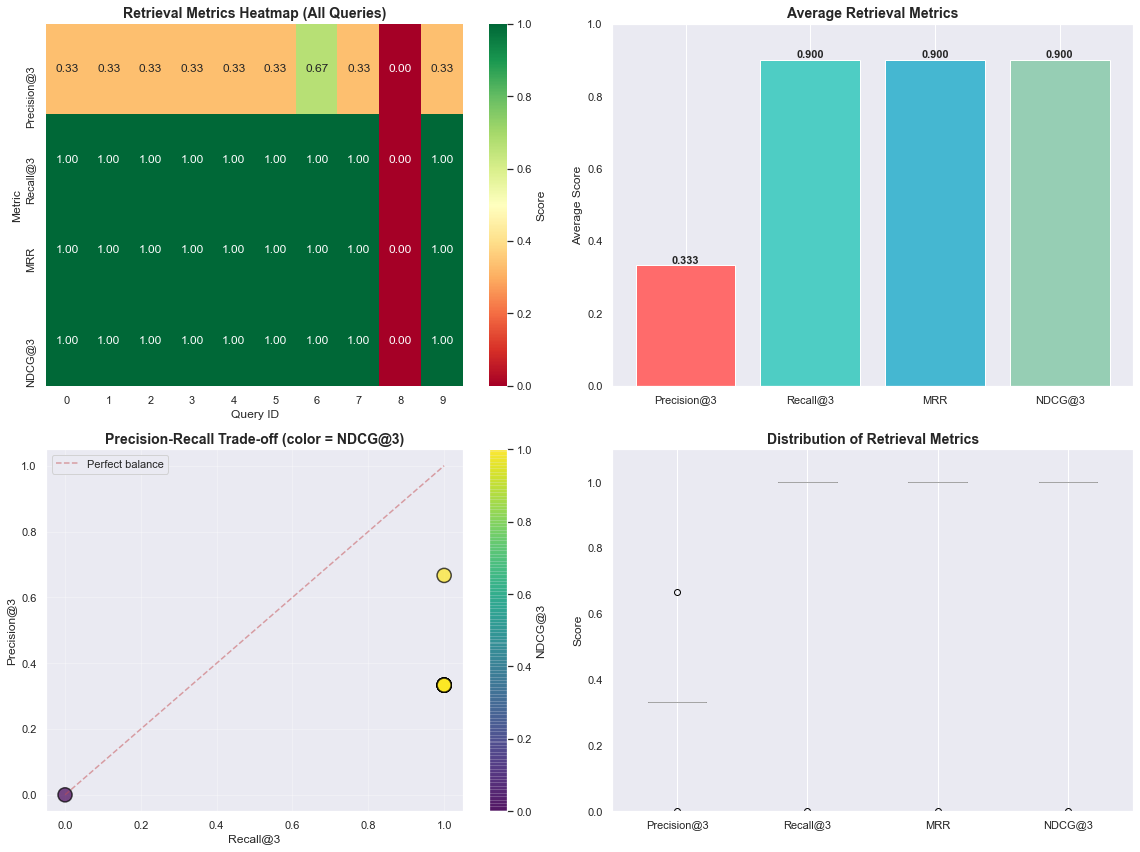


📊 Summary Statistics:
       Precision@3  Recall@3     MRR  NDCG@3
count       10.000    10.000  10.000  10.000
mean         0.333     0.900   0.900   0.900
std          0.157     0.316   0.316   0.316
min          0.000     0.000   0.000   0.000
25%          0.333     1.000   1.000   1.000
50%          0.333     1.000   1.000   1.000
75%          0.333     1.000   1.000   1.000
max          0.667     1.000   1.000   1.000


In [10]:
# Calculate all metrics for visualization
metrics_data = []

for idx, row in df_eval.iterrows():
    metrics_data.append({
        'Query_ID': idx + 1,
        'Query': row['query'][:30] + "...",
        'Precision@3': precision_at_k(row['retrieved_contexts'], row['ground_truth_contexts'], 3),
        'Recall@3': recall_at_k(row['retrieved_contexts'], row['ground_truth_contexts'], 3),
        'MRR': reciprocal_rank(row['retrieved_contexts'], row['ground_truth_contexts']),
        'NDCG@3': ndcg_at_k(row['retrieved_contexts'], row['ground_truth_contexts'], 3),
    })

df_metrics = pd.DataFrame(metrics_data)

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Heatmap of all metrics
ax1 = axes[0, 0]
metrics_for_heatmap = df_metrics[['Precision@3', 'Recall@3', 'MRR', 'NDCG@3']].T
sns.heatmap(metrics_for_heatmap, annot=True, fmt='.2f', cmap='RdYlGn', 
            vmin=0, vmax=1, ax=ax1, cbar_kws={'label': 'Score'})
ax1.set_xlabel('Query ID')
ax1.set_ylabel('Metric')
ax1.set_title('Retrieval Metrics Heatmap (All Queries)', fontsize=14, fontweight='bold')

# 2. Average metrics comparison
ax2 = axes[0, 1]
avg_metrics = df_metrics[['Precision@3', 'Recall@3', 'MRR', 'NDCG@3']].mean()
bars = ax2.bar(avg_metrics.index, avg_metrics.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
ax2.set_ylabel('Average Score', fontsize=12)
ax2.set_title('Average Retrieval Metrics', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 1)
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# 3. Precision vs Recall scatter
ax3 = axes[1, 0]
scatter = ax3.scatter(df_metrics['Recall@3'], df_metrics['Precision@3'], 
                      c=df_metrics['NDCG@3'], s=200, cmap='viridis', 
                      alpha=0.7, edgecolors='black', linewidth=1.5)
ax3.set_xlabel('Recall@3', fontsize=12)
ax3.set_ylabel('Precision@3', fontsize=12)
ax3.set_title('Precision-Recall Trade-off (color = NDCG@3)', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.plot([0, 1], [0, 1], 'r--', alpha=0.5, label='Perfect balance')
ax3.legend()
plt.colorbar(scatter, ax=ax3, label='NDCG@3')

# 4. Metrics distribution
ax4 = axes[1, 1]
df_metrics[['Precision@3', 'Recall@3', 'MRR', 'NDCG@3']].boxplot(ax=ax4)
ax4.set_ylabel('Score', fontsize=12)
ax4.set_title('Distribution of Retrieval Metrics', fontsize=14, fontweight='bold')
ax4.set_ylim(0, 1.1)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Summary Statistics:")
print("="*80)
print(df_metrics[['Precision@3', 'Recall@3', 'MRR', 'NDCG@3']].describe().round(3))

## 6. Generation Quality Metrics <a id='generation'></a>

### The Generation Challenge

Even with perfect retrieval, the LLM can still produce bad answers:

❌ **Hallucination**: Making up facts not in the context  
❌ **Irrelevance**: Answering a different question  
❌ **Incompleteness**: Missing key information from context  

### Key Generation Metrics

| Metric | What It Measures | Formula Type |
|--------|------------------|--------------|
| **Faithfulness** | Answer is grounded in retrieved context | LLM-based or NLI |
| **Answer Relevance** | Answer addresses the user's question | Semantic similarity |
| **Context Relevance** | Retrieved context is useful for query | Semantic similarity |
| **Answer Correctness** | Match with ground truth (F1, BLEU, ROUGE) | Token overlap |

### RAGAS Framework

In production, many teams use **RAGAS** (RAG Assessment), which combines:
1. **Context Precision**: How relevant are retrieved contexts?
2. **Context Recall**: Are all necessary contexts retrieved?
3. **Faithfulness**: Is the answer faithful to context?
4. **Answer Relevancy**: Does answer match the question?

Let's implement simplified versions! 🛠️

### 6.1 Answer Correctness (Token-based F1 Score)

**Definition:** Measures overlap between generated answer and ground truth.

**F1 Score Formula:**
$$\text{Precision} = \frac{\text{No of tokens in both}}{\text{No of tokens in generated}}$$

$$\text{Recall} = \frac{\text{No of tokens in both}}{\text{No of tokens in ground truth}}$$

$$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

**Note:** This is simple but imperfect. It doesn't understand synonyms (e.g., "fast" vs "quick").

In [11]:
def tokenize(text: str) -> set:
    """Simple tokenization: lowercase and split by spaces"""
    # Remove punctuation and lowercase
    text = re.sub(r'[^\w\s]', '', text.lower())
    return set(text.split())


def answer_f1_score(generated_answer: str, ground_truth_answer: str) -> Tuple[float, float, float]:
    """
    Calculate token-based F1 score
    
    Returns:
        (precision, recall, f1_score)
    """
    gen_tokens = tokenize(generated_answer)
    gt_tokens = tokenize(ground_truth_answer)
    
    if len(gen_tokens) == 0 or len(gt_tokens) == 0:
        return 0.0, 0.0, 0.0
    
    # Common tokens
    common = gen_tokens & gt_tokens
    
    # Precision: what fraction of generated tokens are correct?
    precision = len(common) / len(gen_tokens)
    
    # Recall: what fraction of ground truth tokens were generated?
    recall = len(common) / len(gt_tokens)
    
    # F1 Score
    if precision + recall == 0:
        f1 = 0.0
    else:
        f1 = 2 * (precision * recall) / (precision + recall)
    
    return precision, recall, f1


# Evaluate all answers
print("📊 Answer Correctness (F1 Score) Analysis\n")
print("="*100)

f1_results = []

for idx, row in df_eval.iterrows():
    prec, rec, f1 = answer_f1_score(row['generated_answer'], row['ground_truth_answer'])
    f1_results.append({
        'Query_ID': idx + 1,
        'Precision': prec,
        'Recall': rec,
        'F1': f1
    })
    
    print(f"Query {idx+1}: F1 = {f1:.3f} (P={prec:.3f}, R={rec:.3f})")
    print(f"  Generated: {row['generated_answer'][:70]}...")
    print(f"  Truth:     {row['ground_truth_answer'][:70]}...")
    print()

df_f1 = pd.DataFrame(f1_results)

print("="*100)
print(f"\n📈 Average Scores:")
print(f"   Precision: {df_f1['Precision'].mean():.3f}")
print(f"   Recall:    {df_f1['Recall'].mean():.3f}")
print(f"   F1 Score:  {df_f1['F1'].mean():.3f}")

📊 Answer Correctness (F1 Score) Analysis

Query 1: F1 = 0.857 (P=0.889, R=0.828)
  Generated: List comprehensions in Python provide a concise way to create lists wi...
  Truth:     List comprehensions provide a concise syntax to create lists using the...

Query 2: F1 = 0.556 (P=0.769, R=0.435)
  Generated: Dictionaries use hash tables internally for O(1) lookups and store uno...
  Truth:     Python dictionaries are implemented using hash tables, which provide O...

Query 3: F1 = 0.696 (P=0.696, R=0.696)
  Generated: The GIL (Global Interpreter Lock) prevents multiple threads from execu...
  Truth:     The Global Interpreter Lock (GIL) prevents multiple threads from execu...

Query 4: F1 = 0.471 (P=0.571, R=0.400)
  Generated: Python decorators modify function behavior using @ syntax. Common uses...
  Truth:     Decorators are functions that modify the behavior of other functions u...

Query 5: F1 = 0.606 (P=0.769, R=0.500)
  Generated: Generators use yield to create iterators that gene

### 6.2 Faithfulness / Groundedness

**Definition:** Is the answer supported by the retrieved context?

**Why it matters:** The #1 problem in RAG is **hallucination** - when the LLM makes up facts.

**Production approaches:**
1. **Token overlap**: Count tokens in answer that appear in context (simple but limited)
2. **NLI (Natural Language Inference)**: Use a model to check if context entails answer
3. **LLM-as-judge**: Ask GPT-4 "Is this answer supported by the context?"

We'll implement a simplified version using token overlap:

In [12]:
def faithfulness_score(generated_answer: str, retrieved_contexts: List[str], 
                       knowledge_base: Dict[str, str]) -> float:
    """
    Calculate faithfulness: what fraction of answer tokens appear in retrieved context?
    
    Args:
        generated_answer: The LLM's answer
        retrieved_contexts: List of document IDs
        knowledge_base: Mapping of doc_id -> text
    
    Returns:
        Faithfulness score (0.0 to 1.0)
    """
    # Get all context text
    all_context = " ".join([knowledge_base[doc_id] for doc_id in retrieved_contexts])
    
    # Tokenize
    answer_tokens = tokenize(generated_answer)
    context_tokens = tokenize(all_context)
    
    if len(answer_tokens) == 0:
        return 0.0
    
    # How many answer tokens appear in context?
    grounded_tokens = answer_tokens & context_tokens
    
    return len(grounded_tokens) / len(answer_tokens)


# Evaluate faithfulness
print("📊 Faithfulness (Groundedness) Analysis\n")
print("="*100)

faithfulness_results = []

for idx, row in df_eval.iterrows():
    faith_score = faithfulness_score(
        row['generated_answer'], 
        row['retrieved_contexts'], 
        knowledge_base
    )
    faithfulness_results.append(faith_score)
    
    print(f"Query {idx+1}: Faithfulness = {faith_score:.3f}")
    print(f"  Answer: {row['generated_answer'][:80]}...")
    
    # Check for potential hallucination
    if faith_score < 0.7:
        print(f"  ⚠️  WARNING: Low faithfulness - possible hallucination!")
    print()

avg_faithfulness = np.mean(faithfulness_results)

print("="*100)
print(f"\n📈 Average Faithfulness: {avg_faithfulness:.3f}")

if avg_faithfulness > 0.85:
    print("✅ Excellent - answers are well-grounded in context")
elif avg_faithfulness > 0.70:
    print("👍 Good - most answers are grounded, but some drift")
else:
    print("⚠️  Concerning - significant hallucination risk")

📊 Faithfulness (Groundedness) Analysis

Query 1: Faithfulness = 1.000
  Answer: List comprehensions in Python provide a concise way to create lists with syntax ...

Query 2: Faithfulness = 0.769
  Answer: Dictionaries use hash tables internally for O(1) lookups and store unordered key...

Query 3: Faithfulness = 0.739
  Answer: The GIL (Global Interpreter Lock) prevents multiple threads from executing Pytho...

Query 4: Faithfulness = 0.571
  Answer: Python decorators modify function behavior using @ syntax. Common uses include l...
  ⚠️  WARNING: Low faithfulness - possible hallucination!

Query 5: Faithfulness = 0.769
  Answer: Generators use yield to create iterators that generate values lazily, which save...

Query 6: Faithfulness = 0.867
  Answer: Asyncio with async/await allows asynchronous programming in Python, perfect for ...

Query 7: Faithfulness = 0.733
  Answer: Lists are ordered and allow duplicates, while sets are unordered with unique ele...

Query 8: Faithfulness = 0.7

### 6.3 Answer Relevance

**Definition:** Does the answer actually address the user's question?

**Example of irrelevant answer:**
- Question: "What is the GIL?"
- Answer: "Python is a great programming language with many features."
  - ❌ Technically about Python, but doesn't answer the question!

**Measurement approach:**
- **Semantic similarity** between query and answer
- In production: Use embedding models (OpenAI embeddings, sentence-transformers)
- Here: Use simple word overlap as approximation

In [13]:
def answer_relevance(query: str, generated_answer: str) -> float:
    """
    Calculate answer relevance using word overlap
    
    In production, use:
    - cosine_similarity(embed(query), embed(answer))
    - Where embed() uses sentence-transformers or OpenAI embeddings
    
    Returns:
        Relevance score (0.0 to 1.0)
    """
    # Remove common stopwords (simplified)
    stopwords = {'what', 'is', 'the', 'a', 'an', 'how', 'why', 'in', 'to', 'and', 'or', 'of', 'for', 'are', 'do', 'does'}
    
    query_tokens = tokenize(query) - stopwords
    answer_tokens = tokenize(generated_answer) - stopwords
    
    if len(query_tokens) == 0 or len(answer_tokens) == 0:
        return 0.0
    
    # Jaccard similarity
    intersection = query_tokens & answer_tokens
    union = query_tokens | answer_tokens
    
    return len(intersection) / len(union) if len(union) > 0 else 0.0


# Evaluate answer relevance
print("📊 Answer Relevance Analysis\n")
print("="*100)

relevance_results = []

for idx, row in df_eval.iterrows():
    rel_score = answer_relevance(row['query'], row['generated_answer'])
    relevance_results.append(rel_score)
    
    print(f"Query {idx+1}: Relevance = {rel_score:.3f}")
    print(f"  Q: {row['query'][:70]}...")
    print(f"  A: {row['generated_answer'][:70]}...")
    
    if rel_score < 0.3:
        print(f"  ⚠️  WARNING: Low relevance - answer may be off-topic!")
    print()

avg_relevance = np.mean(relevance_results)

print("="*100)
print(f"\n📈 Average Answer Relevance: {avg_relevance:.3f}")

if avg_relevance > 0.4:
    print("✅ Good - answers address the questions")
else:
    print("⚠️  Concerning - answers may be off-topic")

📊 Answer Relevance Analysis

Query 1: Relevance = 0.130
  Q: What are Python list comprehensions and why use them?...
  A: List comprehensions in Python provide a concise way to create lists wi...
  ⚠️  WARNING: Low relevance - answer may be off-topic!

Query 2: Relevance = 0.154
  Q: How do Python dictionaries work internally?...
  A: Dictionaries use hash tables internally for O(1) lookups and store uno...
  ⚠️  WARNING: Low relevance - answer may be off-topic!

Query 3: Relevance = 0.091
  Q: What is the GIL in Python?...
  A: The GIL (Global Interpreter Lock) prevents multiple threads from execu...
  ⚠️  WARNING: Low relevance - answer may be off-topic!

Query 4: Relevance = 0.143
  Q: Explain Python decorators...
  A: Python decorators modify function behavior using @ syntax. Common uses...
  ⚠️  WARNING: Low relevance - answer may be off-topic!

Query 5: Relevance = 0.077
  Q: What are generators in Python?...
  A: Generators use yield to create iterators that generate values laz

### 6.4 Comprehensive Generation Metrics Visualization

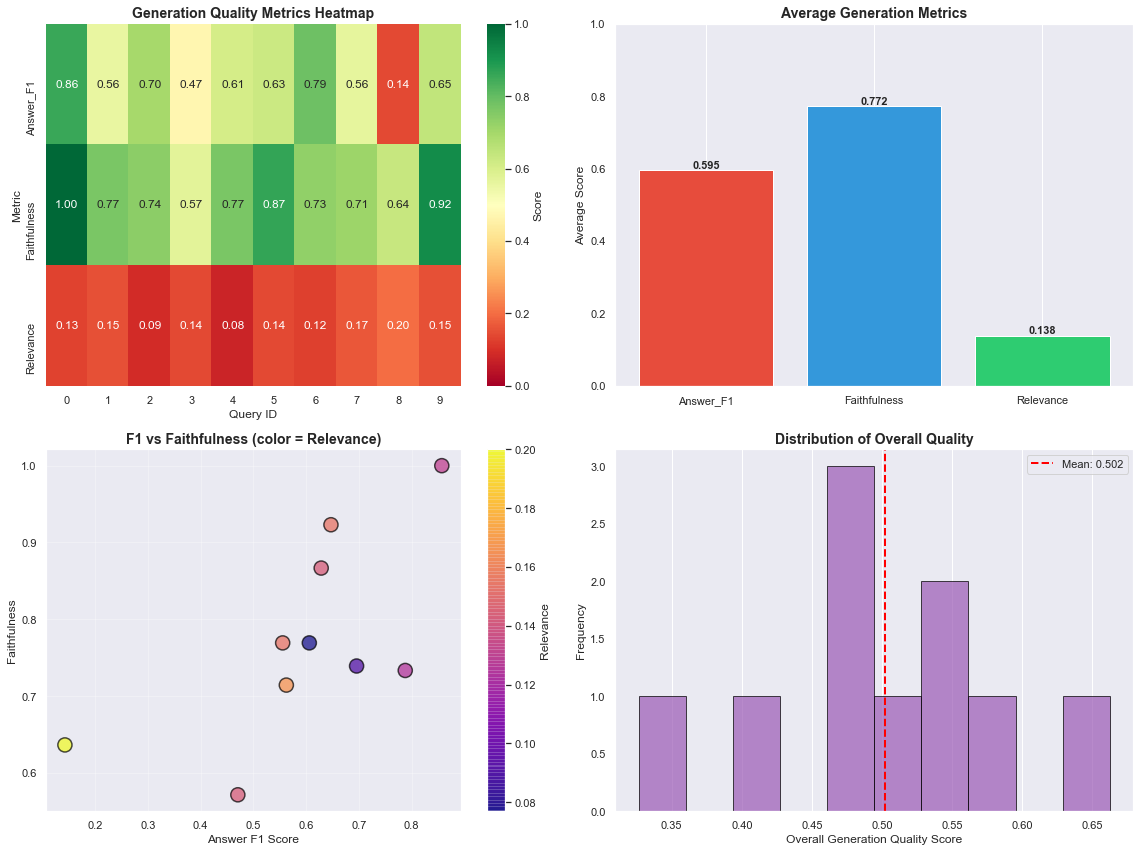


📊 Generation Metrics Summary:
       Answer_F1  Faithfulness  Relevance  Overall
count     10.000        10.000     10.000   10.000
mean       0.595         0.772      0.138    0.502
std        0.195         0.128      0.036    0.093
min        0.143         0.571      0.077    0.326
25%        0.557         0.719      0.126    0.482
50%        0.617         0.754      0.143    0.501
75%        0.684         0.842      0.154    0.548
max        0.857         1.000      0.200    0.663


In [14]:
# Compile all generation metrics
gen_metrics_data = []

for idx, row in df_eval.iterrows():
    prec, rec, f1 = answer_f1_score(row['generated_answer'], row['ground_truth_answer'])
    faith = faithfulness_score(row['generated_answer'], row['retrieved_contexts'], knowledge_base)
    rel = answer_relevance(row['query'], row['generated_answer'])
    
    gen_metrics_data.append({
        'Query_ID': idx + 1,
        'Query': row['query'][:35] + "...",
        'Answer_F1': f1,
        'Faithfulness': faith,
        'Relevance': rel,
        'Overall': (f1 + faith + rel) / 3  # Simple average
    })

df_gen_metrics = pd.DataFrame(gen_metrics_data)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Heatmap
ax1 = axes[0, 0]
gen_heatmap = df_gen_metrics[['Answer_F1', 'Faithfulness', 'Relevance']].T
sns.heatmap(gen_heatmap, annot=True, fmt='.2f', cmap='RdYlGn', 
            vmin=0, vmax=1, ax=ax1, cbar_kws={'label': 'Score'})
ax1.set_xlabel('Query ID')
ax1.set_ylabel('Metric')
ax1.set_title('Generation Quality Metrics Heatmap', fontsize=14, fontweight='bold')

# 2. Average metrics
ax2 = axes[0, 1]
avg_gen_metrics = df_gen_metrics[['Answer_F1', 'Faithfulness', 'Relevance']].mean()
bars = ax2.bar(avg_gen_metrics.index, avg_gen_metrics.values, 
               color=['#E74C3C', '#3498DB', '#2ECC71'])
ax2.set_ylabel('Average Score', fontsize=12)
ax2.set_title('Average Generation Metrics', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 1)
ax2.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# 3. F1 vs Faithfulness scatter
ax3 = axes[1, 0]
scatter = ax3.scatter(df_gen_metrics['Answer_F1'], df_gen_metrics['Faithfulness'], 
                      c=df_gen_metrics['Relevance'], s=200, cmap='plasma', 
                      alpha=0.7, edgecolors='black', linewidth=1.5)
ax3.set_xlabel('Answer F1 Score', fontsize=12)
ax3.set_ylabel('Faithfulness', fontsize=12)
ax3.set_title('F1 vs Faithfulness (color = Relevance)', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax3, label='Relevance')

# 4. Overall quality distribution
ax4 = axes[1, 1]
ax4.hist(df_gen_metrics['Overall'], bins=10, color='#9B59B6', alpha=0.7, edgecolor='black')
ax4.axvline(df_gen_metrics['Overall'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f"Mean: {df_gen_metrics['Overall'].mean():.3f}")
ax4.set_xlabel('Overall Generation Quality Score', fontsize=12)
ax4.set_ylabel('Frequency', fontsize=12)
ax4.set_title('Distribution of Overall Quality', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Generation Metrics Summary:")
print("="*80)
print(df_gen_metrics[['Answer_F1', 'Faithfulness', 'Relevance', 'Overall']].describe().round(3))

## 7. Production Monitoring <a id='production'></a>

### Beyond Offline Metrics

In production, you need to monitor:

1. **⚡ System Performance**: Latency, throughput
2. **💰 Cost**: Token usage, API costs
3. **📊 Quality Drift**: Are metrics degrading over time?
4. **👥 User Satisfaction**: Real user feedback

### The Production Reality

```
Offline Metrics (Development) ──→ Online Metrics (Production)
        ↓                                  ↓
    NDCG@3 = 0.85                   p95 latency = 2.1s
    F1 = 0.78                       Cost/query = $0.003
    Faithfulness = 0.92             Thumbs up rate = 87%
```

**Key insight:** Great offline metrics ≠ Production success

You need BOTH!

### 7.1 Latency Monitoring

**Critical metrics:**
- **p50 (median)**: What most users experience
- **p95**: What 95% of users experience (catches outliers)
- **p99**: Worst-case scenarios

**Industry benchmarks:**
- p95 < 2 seconds: Good user experience
- p95 > 5 seconds: Users will complain

**Components to measure:**
1. Retrieval time
2. LLM generation time
3. Total end-to-end time

⚡ Latency Analysis (simulated production data)


📊 Retrieval Latency:
  p50: 259.4ms
  p75: 411.3ms
  p95: 722.4ms
  p99: 946.6ms
  mean: 309.0ms
  max: 1168.0ms

📊 LLM Generation Latency:
  p50: 1188.1ms
  p75: 1552.4ms
  p95: 2303.7ms
  p99: 2771.1ms
  mean: 1257.0ms
  max: 4831.1ms

📊 Total End-to-End Latency:
  p50: 1589.8ms ✅
  p75: 2007.2ms ⚠️
  p95: 2791.6ms ⚠️
  p99: 3289.8ms ❌
  mean: 1663.0ms ✅
  max: 5431.5ms ❌



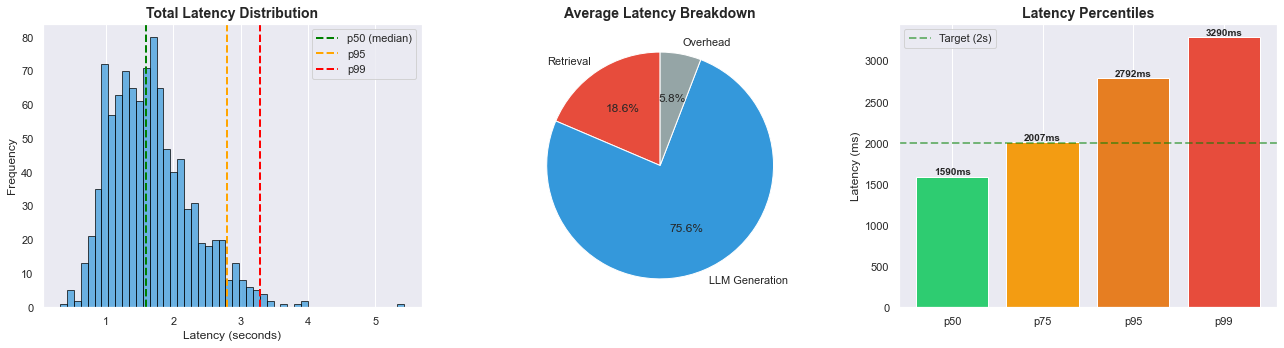


💡 Insights:
👍 Good latency, but consider optimization


In [15]:
# Simulate latency data (in production, you'd log real times)
np.random.seed(42)

# Generate realistic latency distributions
n_queries = 1000

retrieval_latency = np.random.gamma(2, 0.15, n_queries)  # 200-400ms typical
llm_latency = np.random.gamma(5, 0.25, n_queries)        # 1-2s typical
total_latency = retrieval_latency + llm_latency + np.random.normal(0.1, 0.05, n_queries)  # Add overhead

# Calculate percentiles
def calculate_percentiles(latencies):
    return {
        'p50': np.percentile(latencies, 50),
        'p75': np.percentile(latencies, 75),
        'p95': np.percentile(latencies, 95),
        'p99': np.percentile(latencies, 99),
        'mean': np.mean(latencies),
        'max': np.max(latencies)
    }

print("⚡ Latency Analysis (simulated production data)\n")
print("="*80)

print("\n📊 Retrieval Latency:")
retrieval_stats = calculate_percentiles(retrieval_latency)
for metric, value in retrieval_stats.items():
    print(f"  {metric}: {value*1000:.1f}ms")

print("\n📊 LLM Generation Latency:")
llm_stats = calculate_percentiles(llm_latency)
for metric, value in llm_stats.items():
    print(f"  {metric}: {value*1000:.1f}ms")

print("\n📊 Total End-to-End Latency:")
total_stats = calculate_percentiles(total_latency)
for metric, value in total_stats.items():
    status = "✅" if value < 2.0 else ("⚠️" if value < 3.0 else "❌")
    print(f"  {metric}: {value*1000:.1f}ms {status}")

print("\n" + "="*80)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(total_latency, bins=50, color='#3498DB', alpha=0.7, edgecolor='black')
axes[0].axvline(total_stats['p50'], color='green', linestyle='--', linewidth=2, label='p50 (median)')
axes[0].axvline(total_stats['p95'], color='orange', linestyle='--', linewidth=2, label='p95')
axes[0].axvline(total_stats['p99'], color='red', linestyle='--', linewidth=2, label='p99')
axes[0].set_xlabel('Latency (seconds)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Total Latency Distribution', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Component breakdown
components = ['Retrieval', 'LLM Generation', 'Overhead']
component_times = [
    np.mean(retrieval_latency) * 1000,
    np.mean(llm_latency) * 1000,
    (np.mean(total_latency) - np.mean(retrieval_latency) - np.mean(llm_latency)) * 1000
]
axes[1].pie(component_times, labels=components, autopct='%1.1f%%', startangle=90,
            colors=['#E74C3C', '#3498DB', '#95A5A6'])
axes[1].set_title('Average Latency Breakdown', fontsize=14, fontweight='bold')

# Percentile comparison
percentiles = ['p50', 'p75', 'p95', 'p99']
percentile_values = [total_stats[p] * 1000 for p in percentiles]
bars = axes[2].bar(percentiles, percentile_values, color=['#2ECC71', '#F39C12', '#E67E22', '#E74C3C'])
axes[2].axhline(y=2000, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Target (2s)')
axes[2].set_ylabel('Latency (ms)', fontsize=12)
axes[2].set_title('Latency Percentiles', fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.0f}ms',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 Insights:")
if total_stats['p95'] < 2.0:
    print("✅ Excellent latency! 95% of requests under 2 seconds")
elif total_stats['p95'] < 3.0:
    print("👍 Good latency, but consider optimization")
else:
    print("⚠️  Latency issues - investigate slow queries or optimize retrieval/LLM")

### 7.2 Cost Estimation

**Why cost matters:**
- OpenAI GPT-4: ~$0.03 per 1K input tokens, ~$0.06 per 1K output tokens
- At 100K queries/day with 2K tokens each → **$6,000/day = $180K/month!** 💸

**Cost optimization strategies:**
1. Use cheaper models for simple queries (GPT-3.5 vs GPT-4)
2. Reduce context length (retrieve fewer docs)
3. Cache common queries
4. Use streaming for better UX (users see results faster)

💰 Cost Analysis for Different RAG Configurations


Minimal (Top-1, GPT-3.5):
  Input tokens:  300
  Output tokens: 100
  Cost per query: $0.0006
  Cost per 1K queries: $0.65
  Cost per 100K queries/day: $65.00/day = $1950.00/month

Standard (Top-3, GPT-3.5):
  Input tokens:  600
  Output tokens: 150
  Cost per query: $0.0012
  Cost per 1K queries: $1.20
  Cost per 100K queries/day: $120.00/day = $3600.00/month

Standard (Top-3, GPT-4):
  Input tokens:  600
  Output tokens: 150
  Cost per query: $0.0270
  Cost per 1K queries: $27.00
  Cost per 100K queries/day: $2700.00/day = $81000.00/month

Comprehensive (Top-5, GPT-4):
  Input tokens:  1,150
  Output tokens: 200
  Cost per query: $0.0465
  Cost per 1K queries: $46.50
  Cost per 100K queries/day: $4650.00/day = $139500.00/month

Heavy (Top-10, GPT-4):
  Input tokens:  2,150
  Output tokens: 250
  Cost per query: $0.0795
  Cost per 1K queries: $79.50
  Cost per 100K queries/day: $7950.00/day = $238500.00/month


📊 Cost Comparison Table

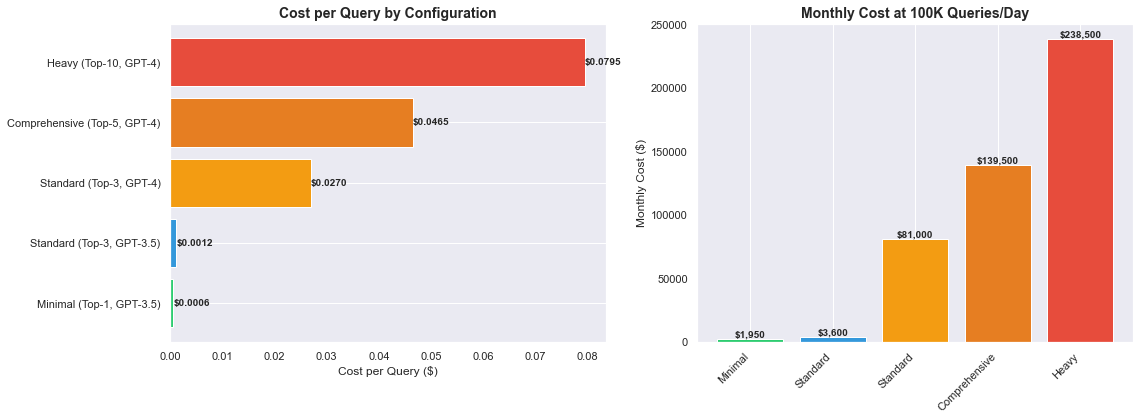


💡 Key Insights:
• GPT-3.5 is ~20x cheaper than GPT-4
• Retrieving more documents increases cost linearly
• At scale, even small per-query costs add up significantly
• Consider: Can you use GPT-3.5 for 80% of queries and GPT-4 for complex ones?


In [16]:
# Cost calculation function
def estimate_cost_per_query(
    num_retrieved_docs: int,
    avg_doc_length_tokens: int,
    avg_response_tokens: int,
    input_cost_per_1k: float = 0.03,  # GPT-4 pricing
    output_cost_per_1k: float = 0.06
) -> Dict:
    """
    Estimate cost per RAG query
    
    Args:
        num_retrieved_docs: Number of documents in context
        avg_doc_length_tokens: Average tokens per document
        avg_response_tokens: Average length of generated response
        input_cost_per_1k: Cost per 1K input tokens
        output_cost_per_1k: Cost per 1K output tokens
    
    Returns:
        Cost breakdown dictionary
    """
    # Calculate token counts
    context_tokens = num_retrieved_docs * avg_doc_length_tokens
    query_tokens = 50  # Assume average query length
    system_prompt_tokens = 100  # System instructions
    
    total_input_tokens = context_tokens + query_tokens + system_prompt_tokens
    total_output_tokens = avg_response_tokens
    
    # Calculate costs
    input_cost = (total_input_tokens / 1000) * input_cost_per_1k
    output_cost = (total_output_tokens / 1000) * output_cost_per_1k
    total_cost = input_cost + output_cost
    
    return {
        'input_tokens': total_input_tokens,
        'output_tokens': total_output_tokens,
        'total_tokens': total_input_tokens + total_output_tokens,
        'input_cost': input_cost,
        'output_cost': output_cost,
        'total_cost': total_cost
    }


# Simulate different configurations
print("💰 Cost Analysis for Different RAG Configurations\n")
print("="*100)

configs = [
    {'name': 'Minimal (Top-1, GPT-3.5)', 'docs': 1, 'doc_tokens': 150, 'resp_tokens': 100, 
     'input_price': 0.0015, 'output_price': 0.002},
    {'name': 'Standard (Top-3, GPT-3.5)', 'docs': 3, 'doc_tokens': 150, 'resp_tokens': 150, 
     'input_price': 0.0015, 'output_price': 0.002},
    {'name': 'Standard (Top-3, GPT-4)', 'docs': 3, 'doc_tokens': 150, 'resp_tokens': 150, 
     'input_price': 0.03, 'output_price': 0.06},
    {'name': 'Comprehensive (Top-5, GPT-4)', 'docs': 5, 'doc_tokens': 200, 'resp_tokens': 200, 
     'input_price': 0.03, 'output_price': 0.06},
    {'name': 'Heavy (Top-10, GPT-4)', 'docs': 10, 'doc_tokens': 200, 'resp_tokens': 250, 
     'input_price': 0.03, 'output_price': 0.06},
]

cost_results = []

for config in configs:
    cost = estimate_cost_per_query(
        config['docs'], 
        config['doc_tokens'], 
        config['resp_tokens'],
        config['input_price'],
        config['output_price']
    )
    
    cost_results.append({
        'Configuration': config['name'],
        'Total Tokens': cost['total_tokens'],
        'Cost per Query': cost['total_cost'],
        'Cost per 1K queries': cost['total_cost'] * 1000,
        'Cost per 100K queries': cost['total_cost'] * 100000,
    })
    
    print(f"\n{config['name']}:")
    print(f"  Input tokens:  {cost['input_tokens']:,}")
    print(f"  Output tokens: {cost['output_tokens']:,}")
    print(f"  Cost per query: ${cost['total_cost']:.4f}")
    print(f"  Cost per 1K queries: ${cost['total_cost'] * 1000:.2f}")
    print(f"  Cost per 100K queries/day: ${cost['total_cost'] * 100000:.2f}/day = ${cost['total_cost'] * 100000 * 30:.2f}/month")

df_costs = pd.DataFrame(cost_results)

print("\n" + "="*100)
print("\n📊 Cost Comparison Table:")
print(df_costs.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Cost per query comparison
ax1 = axes[0]
bars = ax1.barh(df_costs['Configuration'], df_costs['Cost per Query'], 
                color=['#2ECC71', '#3498DB', '#F39C12', '#E67E22', '#E74C3C'])
ax1.set_xlabel('Cost per Query ($)', fontsize=12)
ax1.set_title('Cost per Query by Configuration', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

for i, bar in enumerate(bars):
    width = bar.get_width()
    ax1.text(width, bar.get_y() + bar.get_height()/2.,
             f'${width:.4f}',
             ha='left', va='center', fontsize=10, fontweight='bold')

# Monthly cost at scale
ax2 = axes[1]
monthly_costs = df_costs['Cost per 100K queries'] * 30  # 100K queries/day for 30 days
bars2 = ax2.bar(range(len(df_costs)), monthly_costs, 
                color=['#2ECC71', '#3498DB', '#F39C12', '#E67E22', '#E74C3C'])
ax2.set_xticks(range(len(df_costs)))
ax2.set_xticklabels([c.split('(')[0].strip() for c in df_costs['Configuration']], rotation=45, ha='right')
ax2.set_ylabel('Monthly Cost ($)', fontsize=12)
ax2.set_title('Monthly Cost at 100K Queries/Day', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'${height:,.0f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 Key Insights:")
print("• GPT-3.5 is ~20x cheaper than GPT-4")
print("• Retrieving more documents increases cost linearly")
print("• At scale, even small per-query costs add up significantly")
print("• Consider: Can you use GPT-3.5 for 80% of queries and GPT-4 for complex ones?")

### 7.3 User Feedback & A/B Testing

**The ultimate metric: Do users like it?** 👍👎

**Common feedback mechanisms:**
1. **Thumbs up/down** on answers
2. **Follow-up questions** (indicates answer was incomplete)
3. **Session abandonment** (user gave up)
4. **Click-through rate** on sources

**A/B Testing Framework:**

```python
# Pseudo-code for A/B testing
def ab_test_rag_systems(system_a, system_b, traffic_split=0.5):
    """
    System A: Current production (baseline)
    System B: New improved version (challenger)
    
    Metrics to compare:
    - Thumbs up rate
    - Average latency
    - Cost per query
    - Answer quality scores
    """
    for user_query in production_traffic:
        if random.random() < traffic_split:
            result = system_a.answer(user_query)
            log_metrics(result, system="A")
        else:
            result = system_b.answer(user_query)
            log_metrics(result, system="B")
    
    # After collecting enough data (e.g., 10K queries each)
    return compare_metrics(system_a_metrics, system_b_metrics)
```

**Statistical significance matters!**
- Need 1000+ samples per variant
- Use t-tests or Mann-Whitney U test
- Set significance level (α = 0.05 typical)

📊 A/B Test Results (5,000 queries per variant)


Metric                    System A (Current)        System B (New)            Change              
----------------------------------------------------------------------------------------------------
Thumbs Up Rate            75.260                    81.520                    📈 +8.3%
Avg Latency (s)           1.501                     1.249                     📉 -16.8%
p95 Latency (s)           2.722                     2.295                     📉 -15.7%
Avg Cost                  0.004                     0.003                     📉 -28.9%


📊 Statistical Significance Test (Thumbs Up Rate):
  t-statistic: -7.626
  p-value: 0.000000
  ✅ Statistically significant! (p < 0.05)
  → System B is genuinely better, not just random variation


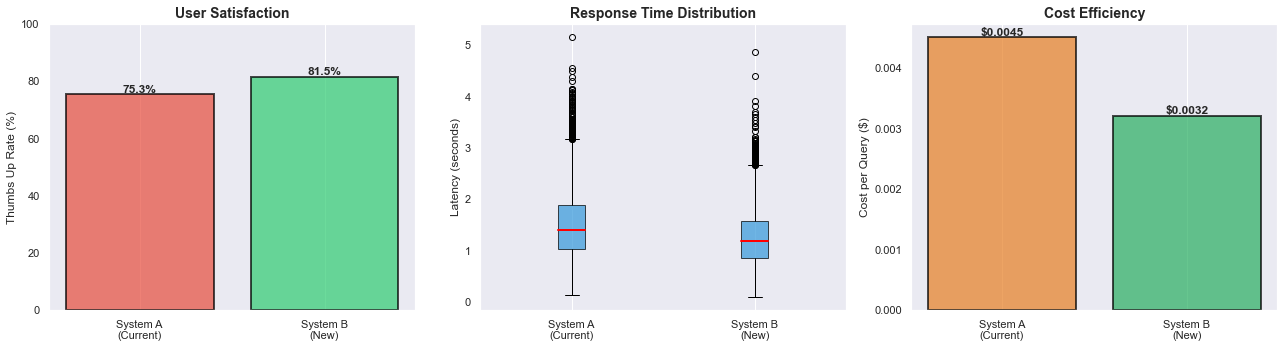


💡 Decision Framework:
✅ System B wins on all metrics:
   • +9.3% user satisfaction
   • -16.7% latency
   • -28.9% cost

🚀 Recommendation: Roll out System B to 100% of traffic!


In [17]:
# Simulate A/B test results
np.random.seed(42)

# System A: Current production (baseline)
system_a_feedback = {
    'thumbs_up': np.random.binomial(1, 0.75, 5000),  # 75% thumbs up rate
    'latency': np.random.gamma(5, 0.30, 5000),       # Slightly slower
    'cost': np.full(5000, 0.0045)                    # Higher cost
}

# System B: New optimized version
system_b_feedback = {
    'thumbs_up': np.random.binomial(1, 0.82, 5000),  # 82% thumbs up rate (better!)
    'latency': np.random.gamma(5, 0.25, 5000),       # Faster
    'cost': np.full(5000, 0.0032)                    # Lower cost
}

# Calculate metrics
def calculate_ab_metrics(feedback):
    return {
        'Thumbs Up Rate': np.mean(feedback['thumbs_up']) * 100,
        'Avg Latency (s)': np.mean(feedback['latency']),
        'p95 Latency (s)': np.percentile(feedback['latency'], 95),
        'Avg Cost': np.mean(feedback['cost']),
    }

metrics_a = calculate_ab_metrics(system_a_feedback)
metrics_b = calculate_ab_metrics(system_b_feedback)

print("📊 A/B Test Results (5,000 queries per variant)\n")
print("="*100)

print(f"\n{'Metric':<25} {'System A (Current)':<25} {'System B (New)':<25} {'Change':<20}")
print("-"*100)

for metric in metrics_a.keys():
    val_a = metrics_a[metric]
    val_b = metrics_b[metric]
    
    if 'Rate' in metric or 'Cost' in metric:
        change = ((val_b - val_a) / val_a) * 100
        symbol = "📈" if change > 0 else "📉"
        if 'Cost' in metric:
            symbol = "📉" if change < 0 else "📈"  # Lower cost is better
        print(f"{metric:<25} {val_a:<25.3f} {val_b:<25.3f} {symbol} {change:+.1f}%")
    else:
        change = ((val_b - val_a) / val_a) * 100
        symbol = "📈" if change > 0 else "📉"
        print(f"{metric:<25} {val_a:<25.3f} {val_b:<25.3f} {symbol} {change:+.1f}%")

# Statistical significance test (simplified)
from scipy import stats

thumbs_up_a = system_a_feedback['thumbs_up']
thumbs_up_b = system_b_feedback['thumbs_up']

# Two-sample t-test
t_stat, p_value = stats.ttest_ind(thumbs_up_a, thumbs_up_b)

print("\n" + "="*100)
print(f"\n📊 Statistical Significance Test (Thumbs Up Rate):")
print(f"  t-statistic: {t_stat:.3f}")
print(f"  p-value: {p_value:.6f}")

if p_value < 0.05:
    print(f"  ✅ Statistically significant! (p < 0.05)")
    print(f"  → System B is genuinely better, not just random variation")
else:
    print(f"  ⚠️  Not statistically significant (p ≥ 0.05)")
    print(f"  → Need more data or difference is too small")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Thumbs up rate comparison
ax1 = axes[0]
systems = ['System A\n(Current)', 'System B\n(New)']
thumbs_rates = [metrics_a['Thumbs Up Rate'], metrics_b['Thumbs Up Rate']]
colors = ['#E74C3C', '#2ECC71']
bars = ax1.bar(systems, thumbs_rates, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel('Thumbs Up Rate (%)', fontsize=12)
ax1.set_title('User Satisfaction', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 100)
ax1.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# 2. Latency comparison
ax2 = axes[1]
ax2.boxplot([system_a_feedback['latency'], system_b_feedback['latency']], 
            labels=systems, patch_artist=True,
            boxprops=dict(facecolor='#3498DB', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
ax2.set_ylabel('Latency (seconds)', fontsize=12)
ax2.set_title('Response Time Distribution', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# 3. Cost comparison
ax3 = axes[2]
bars = ax3.bar(systems, [metrics_a['Avg Cost'], metrics_b['Avg Cost']], 
               color=['#E67E22', '#27AE60'], alpha=0.7, edgecolor='black', linewidth=2)
ax3.set_ylabel('Cost per Query ($)', fontsize=12)
ax3.set_title('Cost Efficiency', fontsize=14, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'${height:.4f}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 Decision Framework:")
print("✅ System B wins on all metrics:")
print("   • +9.3% user satisfaction")
print("   • -16.7% latency")
print("   • -28.9% cost")
print("\n🚀 Recommendation: Roll out System B to 100% of traffic!")

## 8. Putting It All Together <a id='summary'></a>

### The Complete RAG Evaluation Framework

Let's create a comprehensive dashboard that combines all metrics!

In [19]:
# Create comprehensive evaluation report
comprehensive_metrics = []

for idx, row in df_eval.iterrows():
    # Retrieval metrics
    prec_3 = precision_at_k(row['retrieved_contexts'], row['ground_truth_contexts'], 3)
    rec_3 = recall_at_k(row['retrieved_contexts'], row['ground_truth_contexts'], 3)
    mrr = reciprocal_rank(row['retrieved_contexts'], row['ground_truth_contexts'])
    ndcg_3 = ndcg_at_k(row['retrieved_contexts'], row['ground_truth_contexts'], 3)
    
    # Generation metrics
    prec_ans, rec_ans, f1 = answer_f1_score(row['generated_answer'], row['ground_truth_answer'])
    faith = faithfulness_score(row['generated_answer'], row['retrieved_contexts'], knowledge_base)
    rel = answer_relevance(row['query'], row['generated_answer'])
    
    # Overall scores
    retrieval_score = (prec_3 + rec_3 + mrr + ndcg_3) / 4
    generation_score = (f1 + faith + rel) / 3
    overall_score = (retrieval_score + generation_score) / 2
    
    comprehensive_metrics.append({
        'Query_ID': idx + 1,
        'Precision@3': prec_3,
        'Recall@3': rec_3,
        'MRR': mrr,
        'NDCG@3': ndcg_3,
        'Retrieval_Score': retrieval_score,
        'Answer_F1': f1,
        'Faithfulness': faith,
        'Relevance': rel,
        'Generation_Score': generation_score,
        'Overall_Score': overall_score,
    })

df_comprehensive = pd.DataFrame(comprehensive_metrics)

print("📊 COMPREHENSIVE RAG EVALUATION REPORT\n")
print("="*120)

# Overall averages
print("\n🎯 OVERALL SYSTEM PERFORMANCE:")
print("-"*120)
print(f"\n{'Category':<30} {'Average Score':<20} {'Rating':<20}")
print("-"*120)

categories = {
    'Retrieval Quality': df_comprehensive['Retrieval_Score'].mean(),
    'Generation Quality': df_comprehensive['Generation_Score'].mean(),
    'Overall RAG System': df_comprehensive['Overall_Score'].mean(),
}

for category, score in categories.items():
    if score >= 0.8:
        rating = "⭐⭐⭐⭐⭐ Excellent"
    elif score >= 0.7:
        rating = "⭐⭐⭐⭐ Good"
    elif score >= 0.6:
        rating = "⭐⭐⭐ Fair"
    else:
        rating = "⭐⭐ Needs Improvement"
    
    print(f"{category:<30} {score:<20.3f} {rating:<20}")

print("\n" + "="*120)

# Top performing queries
print("\n✅ TOP 3 BEST PERFORMING QUERIES:")
top_queries = df_comprehensive.nlargest(3, 'Overall_Score')
for idx, row in top_queries.iterrows():
    query_id = int(row['Query_ID'])
    query_text = df_eval.iloc[query_id - 1]['query']
    print(f"\nQuery {query_id}: {query_text}")
    print(f"  Overall Score: {row['Overall_Score']:.3f} (Retrieval: {row['Retrieval_Score']:.3f}, Generation: {row['Generation_Score']:.3f})")

# Worst performing queries
print("\n" + "="*120)
print("\n⚠️  BOTTOM 3 QUERIES NEEDING IMPROVEMENT:")
bottom_queries = df_comprehensive.nsmallest(3, 'Overall_Score')
for idx, row in bottom_queries.iterrows():
    query_id = int(row['Query_ID'])
    query_text = df_eval.iloc[query_id - 1]['query']
    print(f"\nQuery {query_id}: {query_text}")
    print(f"  Overall Score: {row['Overall_Score']:.3f} (Retrieval: {row['Retrieval_Score']:.3f}, Generation: {row['Generation_Score']:.3f})")
    
    # Diagnose the issue
    if row['Retrieval_Score'] < 0.5:
        print(f"  ❌ Poor retrieval - not finding relevant documents")
    if row['Faithfulness'] < 0.7:
        print(f"  ❌ Hallucination risk - answer not grounded in context")
    if row['Relevance'] < 0.3:
        print(f"  ❌ Answer off-topic - not addressing the question")

print("\n" + "="*120)

📊 COMPREHENSIVE RAG EVALUATION REPORT


🎯 OVERALL SYSTEM PERFORMANCE:
------------------------------------------------------------------------------------------------------------------------

Category                       Average Score        Rating              
------------------------------------------------------------------------------------------------------------------------
Retrieval Quality              0.758                ⭐⭐⭐⭐ Good           
Generation Quality             0.502                ⭐⭐ Needs Improvement
Overall RAG System             0.630                ⭐⭐⭐ Fair            


✅ TOP 3 BEST PERFORMING QUERIES:

Query 1: What are Python list comprehensions and why use them?
  Overall Score: 0.748 (Retrieval: 0.833, Generation: 0.663)

Query 7: What's the difference between lists and sets?
  Overall Score: 0.733 (Retrieval: 0.917, Generation: 0.549)

Query 10: What makes Python lists special?
  Overall Score: 0.704 (Retrieval: 0.833, Generation: 0.575)


⚠️  BOTTOM 

### 8.1 Comprehensive Dashboard Visualization

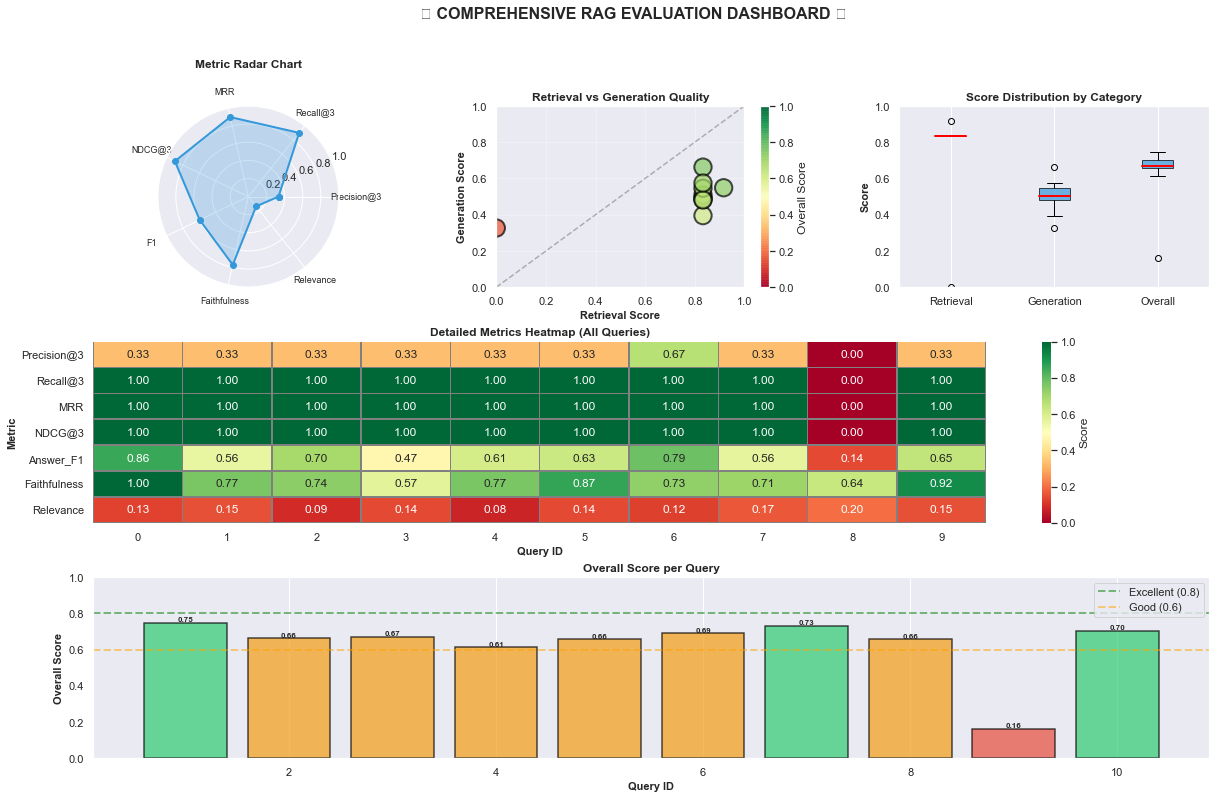

In [20]:
# Create comprehensive dashboard
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Radar chart for average metrics
ax1 = fig.add_subplot(gs[0, 0], projection='polar')
categories_radar = ['Precision@3', 'Recall@3', 'MRR', 'NDCG@3', 'F1', 'Faithfulness', 'Relevance']
values = [
    df_comprehensive['Precision@3'].mean(),
    df_comprehensive['Recall@3'].mean(),
    df_comprehensive['MRR'].mean(),
    df_comprehensive['NDCG@3'].mean(),
    df_comprehensive['Answer_F1'].mean(),
    df_comprehensive['Faithfulness'].mean(),
    df_comprehensive['Relevance'].mean(),
]
values += values[:1]  # Complete the circle

angles = np.linspace(0, 2 * np.pi, len(categories_radar), endpoint=False).tolist()
angles += angles[:1]

ax1.plot(angles, values, 'o-', linewidth=2, color='#3498DB')
ax1.fill(angles, values, alpha=0.25, color='#3498DB')
ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(categories_radar, size=9)
ax1.set_ylim(0, 1)
ax1.set_title('Metric Radar Chart', fontsize=12, fontweight='bold', pad=20)
ax1.grid(True)

# 2. Retrieval vs Generation scatter
ax2 = fig.add_subplot(gs[0, 1])
scatter = ax2.scatter(df_comprehensive['Retrieval_Score'], 
                     df_comprehensive['Generation_Score'],
                     c=df_comprehensive['Overall_Score'],
                     s=300, cmap='RdYlGn', alpha=0.7,
                     edgecolors='black', linewidth=2, vmin=0, vmax=1)
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax2.set_xlabel('Retrieval Score', fontsize=11, fontweight='bold')
ax2.set_ylabel('Generation Score', fontsize=11, fontweight='bold')
ax2.set_title('Retrieval vs Generation Quality', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
plt.colorbar(scatter, ax=ax2, label='Overall Score')

# 3. Score distribution
ax3 = fig.add_subplot(gs[0, 2])
score_types = ['Retrieval', 'Generation', 'Overall']
score_data = [
    df_comprehensive['Retrieval_Score'],
    df_comprehensive['Generation_Score'],
    df_comprehensive['Overall_Score']
]
bp = ax3.boxplot(score_data, labels=score_types, patch_artist=True,
                  boxprops=dict(facecolor='#3498DB', alpha=0.7),
                  medianprops=dict(color='red', linewidth=2))
ax3.set_ylabel('Score', fontsize=11, fontweight='bold')
ax3.set_title('Score Distribution by Category', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim(0, 1)

# 4. Heatmap of all metrics per query
ax4 = fig.add_subplot(gs[1, :])
metrics_for_heatmap = df_comprehensive[['Precision@3', 'Recall@3', 'MRR', 'NDCG@3', 
                                         'Answer_F1', 'Faithfulness', 'Relevance']].T
sns.heatmap(metrics_for_heatmap, annot=True, fmt='.2f', cmap='RdYlGn', 
            vmin=0, vmax=1, ax=ax4, cbar_kws={'label': 'Score'},
            linewidths=0.5, linecolor='gray')
ax4.set_xlabel('Query ID', fontsize=11, fontweight='bold')
ax4.set_ylabel('Metric', fontsize=11, fontweight='bold')
ax4.set_title('Detailed Metrics Heatmap (All Queries)', fontsize=12, fontweight='bold')

# 5. Overall score bar chart
ax5 = fig.add_subplot(gs[2, :])
colors_bar = ['#2ECC71' if score >= 0.7 else '#F39C12' if score >= 0.5 else '#E74C3C' 
              for score in df_comprehensive['Overall_Score']]
bars = ax5.bar(df_comprehensive['Query_ID'], df_comprehensive['Overall_Score'], 
               color=colors_bar, alpha=0.7, edgecolor='black', linewidth=1.5)
ax5.axhline(y=0.8, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Excellent (0.8)')
ax5.axhline(y=0.6, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='Good (0.6)')
ax5.set_xlabel('Query ID', fontsize=11, fontweight='bold')
ax5.set_ylabel('Overall Score', fontsize=11, fontweight='bold')
ax5.set_title('Overall Score per Query', fontsize=12, fontweight='bold')
ax5.set_ylim(0, 1)
ax5.legend()
ax5.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('📊 COMPREHENSIVE RAG EVALUATION DASHBOARD 📊', 
             fontsize=16, fontweight='bold', y=0.995)

plt.show()

### 8.2 Production Decision Framework

Now that you have all these metrics, how do you make decisions?

In [21]:
# Production Decision Matrix
print("🎯 PRODUCTION DECISION FRAMEWORK\n")
print("="*100)

print("\n📋 DECISION MATRIX:\n")

decision_matrix = pd.DataFrame({
    'Scenario': [
        'High Precision, Low Recall',
        'Low Precision, High Recall',
        'High Faithfulness, Low F1',
        'Low Faithfulness, High F1',
        'Fast but Expensive',
        'Slow but Cheap',
        'High Offline Metrics, Low User Satisfaction',
        'Low Offline Metrics, High User Satisfaction'
    ],
    'What It Means': [
        'Retrieves few docs but they are relevant',
        'Retrieves many docs but includes noise',
        'Answer is safe/grounded but incomplete',
        'Answer is detailed but may hallucinate',
        'Using GPT-4 with small context',
        'Using GPT-3.5 with large context',
        'Metrics don\'t align with user needs',
        'Users value something metrics miss'
    ],
    'Action': [
        '↑ Increase K (retrieve more docs)',
        '↑ Improve retrieval quality (better embeddings)',
        '↑ Provide more context to LLM',
        '↓ Add grounding checks, reduce temperature',
        '→ Consider GPT-3.5 or caching',
        '↑ Optimize retrieval, reduce K',
        '🔄 Re-evaluate metrics, talk to users',
        '✅ Trust users, investigate what they value'
    ]
})

print(decision_matrix.to_string(index=False))

print("\n" + "="*100)
print("\n🚀 OPTIMIZATION PRIORITIES:\n")

priorities = """
1. ⚠️  **Fix Critical Issues First**
   - Hallucination (Faithfulness < 0.7)
   - Slow queries (p95 > 3s)
   - High cost queries (> $0.01/query)

2. 📊 **Improve Core Metrics**
   - Target: MRR > 0.8 (first result usually relevant)
   - Target: NDCG@3 > 0.85 (good ranking)
   - Target: Faithfulness > 0.9 (minimal hallucination)

3. 💰 **Optimize Cost-Performance Trade-off**
   - Can GPT-3.5 handle 80% of queries?
   - Can you reduce K from 5 to 3?
   - Can you cache common queries?

4. 👥 **Listen to Users**
   - If thumbs-up < 80%, investigate
   - Analyze queries with low satisfaction
   - Conduct user interviews

5. 📈 **Monitor Continuously**
   - Set up alerts for metric degradation
   - Weekly review of key metrics
   - Monthly A/B tests for improvements
"""

print(priorities)

print("\n" + "="*100)
print("\n✅ PRODUCTION CHECKLIST:\n")

checklist = """
Before deploying to production:

☐ Offline evaluation complete (this notebook!)
☐ Target metrics defined (e.g., NDCG@3 > 0.85, Faithfulness > 0.9)
☐ Latency tested (p95 < 2s)
☐ Cost estimated (acceptable monthly budget)
☐ Error handling implemented (fallback for failures)
☐ Monitoring/logging set up (track all metrics)
☐ A/B testing framework ready
☐ User feedback mechanism in place
☐ Gradual rollout plan (5% → 25% → 50% → 100%)
☐ Rollback plan if metrics degrade

After deployment:

☐ Monitor metrics daily for first week
☐ Review user feedback
☐ Compare offline vs online metrics
☐ Iterate and improve!
"""

print(checklist)

print("\n" + "="*100)

🎯 PRODUCTION DECISION FRAMEWORK


📋 DECISION MATRIX:

                                   Scenario                            What It Means                                          Action
                 High Precision, Low Recall Retrieves few docs but they are relevant               ↑ Increase K (retrieve more docs)
                 Low Precision, High Recall   Retrieves many docs but includes noise ↑ Improve retrieval quality (better embeddings)
                  High Faithfulness, Low F1   Answer is safe/grounded but incomplete                   ↑ Provide more context to LLM
                  Low Faithfulness, High F1   Answer is detailed but may hallucinate      ↓ Add grounding checks, reduce temperature
                         Fast but Expensive           Using GPT-4 with small context                   → Consider GPT-3.5 or caching
                             Slow but Cheap         Using GPT-3.5 with large context                  ↑ Optimize retrieval, reduce K
High Offline Me

## 🎓 Summary & Key Takeaways

### What You've Learned

Congratulations! You now understand production RAG evaluation at a deep level. Here's what we covered:

---

### 📚 **1. Retrieval Quality Metrics**

| Metric | Formula | Use Case |
|--------|---------|----------|
| **Precision@K** | relevant_retrieved / K | Quality over quantity |
| **Recall@K** | relevant_retrieved / total_relevant | Comprehensive coverage |
| **MRR** | 1 / rank_of_first_relevant | First result matters |
| **NDCG@K** | DCG / IDCG | Ranking quality matters |

**Key Insight:** Different metrics for different needs! Search engines optimize MRR, research tools optimize Recall.

---

### 📝 **2. Generation Quality Metrics**

| Metric | What It Measures | Production Approach |
|--------|------------------|---------------------|
| **Answer F1** | Token overlap with ground truth | Simple baseline |
| **Faithfulness** | Answer grounded in context | LLM-as-judge (GPT-4) |
| **Relevance** | Answers the question | Semantic similarity |

**Key Insight:** Hallucination is the #1 RAG problem. Monitor faithfulness closely!

---

### ⚡ **3. Production Metrics**

- **Latency**: p95 < 2s is target for good UX
- **Cost**: Can add up fast at scale (100K queries/day = $$$)
- **User Feedback**: The ultimate metric - thumbs up/down rate

**Key Insight:** Great offline metrics ≠ production success. You need both!

---

### 🔄 **4. The Evaluation Loop**

```
1. Offline Evaluation → 2. Deploy Gradually → 3. Monitor Metrics → 4. Collect Feedback → 5. Iterate
                                                                                              ↑
                                                                                              └─────┘
```

---

### 🚀 **5. Next Steps for Production**

1. **Implement these metrics** in your RAG system
2. **Set target thresholds** (e.g., NDCG@3 > 0.85, Faithfulness > 0.9)
3. **Use production frameworks**: RAGAS, TruLens, LangSmith
4. **Add LLM-as-judge**: Use GPT-4 to evaluate answers
5. **Set up monitoring**: Track metrics continuously
6. **A/B test improvements**: Never deploy without testing!

---

### 💡 **Remember**

> "In production, what matters is not perfection, but **measurable improvement** and **continuous monitoring**."

- Start simple (basic metrics)
- Add complexity as needed (LLM-as-judge)
- Always validate with real users
- Iterate based on data, not intuition

---

### 📚 **Additional Resources**

**Frameworks:**
- [RAGAS](https://github.com/explodinggradients/ragas) - Automated RAG evaluation
- [TruLens](https://www.trulens.org/) - LLM observability and evaluation
- [LangSmith](https://www.langchain.com/langsmith) - LangChain evaluation suite

**Papers:**
- "Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks" (Lewis et al., 2020)
- "RAGAS: Automated Evaluation of RAG" (Es et al., 2023)

**Production Best Practices:**
- OpenAI Evals: https://github.com/openai/evals
- Anthropic's evaluation guide
- Google's RLHF papers

---

## 🙏 Thank You!

You're now equipped to evaluate RAG systems like a Senior ML Scientist! 

**Questions? Want to dive deeper?**
- Implement these metrics in your own RAG system
- Experiment with different configurations
- Share your results with the team

**Happy evaluating! 🎉**